In [48]:
print("Hi")

Hi


In [49]:
%pwd

'd:\\'

In [ ]:
import os
import json

os.chdir("../")

def parse_json_response(text: str):
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        start = text.find("{")
        end = text.rfind("}")
        if start != -1 and end != -1 and end > start:
            return json.loads(text[start:end+1])
        raise

In [50]:
import os
os.chdir('d:/medical-chatbot')

In [51]:
%pwd

'd:\\medical-chatbot'

In [52]:
from langchain.document_loaders import PyPDFLoader, DirectoryLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [53]:
# Extract data from PDF files
def load_pdf_file(data):
    loader = DirectoryLoader(data, glob="*.pdf", loader_cls=PyPDFLoader)
    documents = loader.load()
    return documents

In [54]:
extracted_data = load_pdf_file(data="Data/")

In [55]:
# Split the data into text chunks
def text_split(extracted_data):
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
    text_chunks = text_splitter.split_documents(extracted_data)
    return text_chunks

In [56]:
text_chunks = text_split(extracted_data)

In [57]:
len(text_chunks)

7093

In [58]:
from langchain.embeddings import HuggingFaceEmbeddings

In [59]:
# 384 dimensional vector embeddings
def download_huggingface_embeddings():
    embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
    return embeddings

In [60]:
embeddings = download_huggingface_embeddings()

In [61]:
query_result = embeddings.embed_query("Hello world")
print("length", len(query_result))

length 384


In [62]:
from dotenv import load_dotenv
load_dotenv()

True

In [63]:
PINECONE_API_KEY = os.environ.get("PINECONE_API_KEY")
GROQ_API_KEY = os.environ.get("GROQ_API_KEY")


In [64]:
from pinecone.grpc import PineconeGRPC as Pinecone
from pinecone import ServerlessSpec
import os

pc = Pinecone(api_key=PINECONE_API_KEY)
index_name = "medicalbot"

pc.create_index(
    name=index_name,
    dimension=384,
    metric="cosine",
    spec=ServerlessSpec(
        cloud="aws",
        region="us-east-1"
    )
)

PineconeApiException: (409)
Reason: Conflict
HTTP response headers: HTTPHeaderDict({'content-type': 'text/plain; charset=utf-8', 'vary': 'origin, access-control-request-method, access-control-request-headers', 'access-control-allow-origin': '*', 'access-control-expose-headers': '*', 'x-pinecone-api-version': '2024-07', 'x-cloud-trace-context': 'fec864e8757dbce591549016a257cfcf', 'date': 'Sat, 18 Apr 2026 08:48:49 GMT', 'server': 'Google Frontend', 'Content-Length': '85', 'Via': '1.1 google', 'Alt-Svc': 'h3=":443"; ma=2592000,h3-29=":443"; ma=2592000'})
HTTP response body: {"error":{"code":"ALREADY_EXISTS","message":"Resource  already exists"},"status":409}


In [65]:
import os
# Set the Pinecone API key as an environment variable so that we don't need to write it frequently
os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [66]:
# Embed each chunk and upsert embedding vectors to Pinecone
from langchain_pinecone import PineconeVectorStore

docsearch = PineconeVectorStore.from_documents(
    documents=text_chunks,
    embedding=embeddings,
    index_name=index_name,
)

In [67]:
# Load existing index
from langchain_pinecone import PineconeVectorStore
docsearch = PineconeVectorStore.from_existing_index(
    embedding=embeddings,
    index_name=index_name,
)

In [68]:
docsearch

In [69]:
retriever = docsearch.as_retriever(search_type="similarity", search_kwargs={"k": 3})
# retriever.get_relevant_documents("What are the symptoms of diabetes?")

In [70]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    groq_api_key=GROQ_API_KEY,
    model_name="llama-3.1-8b-instant",

    temperature=0.3,
    max_tokens=500
)


In [71]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END


In [72]:
# -----------------------------
# Graph State
# -----------------------------
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    # Post-generation verification
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

In [73]:
# -----------------------------
# 1) Decide retrieval
# -----------------------------
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON with key: should_retrieve (boolean).\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts from the medical documents.\n"
            "- should_retrieve=False for general explanations/definitions which a simple LLM model can answer.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)

should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: State):
    out = llm.invoke(decide_retrieval_prompt.format_messages(question=state["question"]))
    decision = parse_json_response(out.content)
    return {"need_retrieval": decision["should_retrieve"]}

def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    return "retrieve" if state["need_retrieval"] else "generate_direct"

In [74]:
# -----------------------------
# 2) Direct answer (no retrieval)
# -----------------------------
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer using only your general knowledge.\n"
            "If it requires specific medical info, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)

def generate_direct(state: State):
    out = llm.invoke(direct_generation_prompt.format_messages(question=state["question"]))
    return {"answer": out.content}

In [75]:
# -----------------------------
# 3) Retrieve
# -----------------------------
def retrieve(state: State):
    return {"docs": retriever.get_relevant_documents(state["question"])}

In [76]:
# -----------------------------
# 4) Relevance filter 
# -----------------------------
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True ONLY if the document contains info that can directly answer the question."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are evaluating whether a retrieved medical document can help answer a user's medical question.\n"
            "Return JSON matching the schema.\n\n"
            
            "A document is relevant if it contains information that can directly or indirectly help answer the question.\n"
            "It may include symptoms, causes, diagnosis, treatment, medications, or related medical explanations.\n\n"
            
            "Examples:\n"
            "- A document describing symptoms of diabetes is relevant to a question about diabetes symptoms.\n"
            "- A document about treatment of hypertension is relevant to questions about managing high blood pressure.\n"
            "- A document explaining causes of chest pain is relevant to a query about chest pain reasons.\n"
            "- A document about a completely different disease is NOT relevant.\n\n"
            
            "The document does NOT need to contain the exact final answer,\n"
            "but it must contain useful medical information related to the question.\n\n"
            
            "If the document is unrelated to the medical topic in the question, return is_relevant=false.\n"
            "If unsure, return is_relevant=true."
        ),
        ("human", "Question:\n{question}\n\nDocument:\n{document}"),
    ]
)


relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    relevant_docs: List[Document] = []
    for doc in state.get("docs", []):
        out = llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content,
            )
        )
        decision = parse_json_response(out.content)
        if decision.get("is_relevant"):
            relevant_docs.append(doc)
    return {"relevant_docs": relevant_docs}

def route_after_relevance(state: State) -> Literal["generate_from_context", "no_answer_found"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "no_answer_found"

In [77]:
# -----------------------------
# 5) Generate from context
# -----------------------------
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a medical assistant chatbot.\n\n"
            "You are given CONTEXT extracted from a medical reference book.\n"
            
            "Task:\n"
            "Answer the user's question strictly based on the provided context.\n\n"
            
            "Rules:\n"
            "- Use only the information present in the context.\n"
            "- Do NOT add any external knowledge.\n"
            "- If the context partially answers the question, respond with the available information only.\n"
            "- If the answer is not present, say: 'I don't know based on the provided information.'\n"
            "- Do NOT mention the word 'context' in your answer.\n"
        ),
        ("human", "Question:\n{question}\n\nContext:\n{context}"),
    ]
)

def generate_from_context(state: State):
    context = "\n\n---\n\n".join([d.page_content for d in state.get("relevant_docs", [])]).strip()
    if not context:
        return {"answer": "No answer found.", "context": ""}
    out = llm.invoke(
        rag_generation_prompt.format_messages(question=state["question"], context=context)
    )
    return {"answer": out.content, "context": context}

def no_answer_found(state: State):
    return {"answer": "No answer found.", "context": ""}

In [78]:
# -----------------------------
# 6) IsSUP verify + revise loop
# -----------------------------
class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str] = Field(default_factory=list)

issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a medical fact-checking assistant.\n"
            "Your task is to verify whether the ANSWER is supported by the CONTEXT.\n\n"
            
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            
            "Evaluation criteria:\n"
            
            "- fully_supported:\n"
            "  Every medical claim (symptoms, causes, diagnosis, treatment, medications,etc) is directly supported by the CONTEXT.\n\n"
            
            "- partially_supported:\n"
            "  Some claims are supported, but the answer includes additional medical information not present in CONTEXT.\n\n"
            
            "- no_support:\n"
            "  The main claims are not supported or contradict the CONTEXT.\n\n"
            
            "Examples:\n\n"
            
            "Example 1:\n"
            "CONTEXT: 'Symptoms of diabetes include increased thirst and frequent urination.'\n"
            "ANSWER: 'Diabetes symptoms include increased thirst and frequent urination.'\n"
            "OUTPUT: fully_supported\n\n"
            
            "Example 2:\n"
            "CONTEXT: 'Symptoms of diabetes include increased thirst and frequent urination.'\n"
            "ANSWER: 'Diabetes symptoms include increased thirst, frequent urination, and fatigue.'\n"
            "OUTPUT: partially_supported\n"
            "Reason: 'fatigue' is not present in CONTEXT.\n\n"
            
            "Example 3:\n"
            "CONTEXT: 'Hypertension treatment includes ACE inhibitors.'\n"
            "ANSWER: 'Hypertension is treated using insulin.'\n"
            "OUTPUT: no_support\n"
            "Reason: incorrect and unsupported treatment.\n\n"
            
            "Strict rules:\n"
            "- Be extremely strict.\n"
            "- Do NOT use outside medical knowledge.\n"
            "- Even small unsupported additions → partially_supported.\n"
            "- Contradictions → no_support.\n\n"
            
            "Evidence:\n"
            "- Provide up to 3 short exact quotes from CONTEXT.\n"
            "- If no support exists, return an empty list.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)


issup_llm = llm.with_structured_output(IsSUPDecision)

def is_sup(state: State):
    out = llm.invoke(
        issup_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    decision = parse_json_response(out.content)
    return {
        "issup": decision["issup"],
        "evidence": decision.get("evidence", []),
    }


MAX_RETRIES = 4

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:
    # accept if fully supported
    if state.get("issup") == "fully_supported":
        return "accept_answer"

    # stop if we've already tried enough
    if state.get("retries", 0) >= MAX_RETRIES:

        return "accept_answer"   # or return a "give_up" node if you want    return "revise_answer"

    # otherwise revise again

In [79]:
def accept_answer(state: State):
    return {}  # keep answer as-is

In [80]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)



def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,  # increment retries
    }

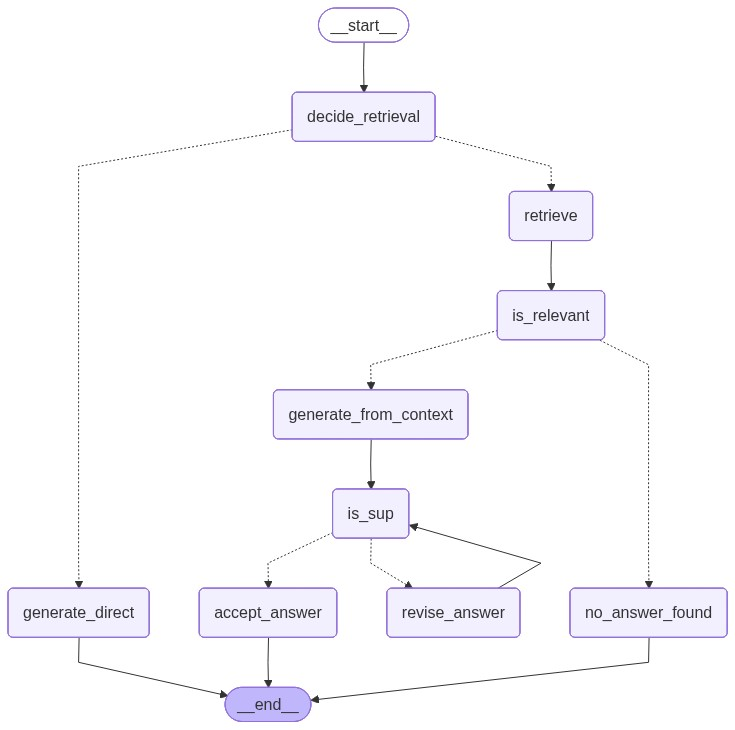

In [81]:
# -----------------------------
# Build graph (REVISED: add accept/revise + loop back to is_sup)
# -----------------------------
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)
g.add_node("no_answer_found", no_answer_found)

g.add_node("is_sup", is_sup)

g.add_node("accept_answer", accept_answer)
g.add_node("revise_answer", revise_answer)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {"generate_direct": "generate_direct", "retrieve": "retrieve"},
)

g.add_edge("generate_direct", END)

g.add_edge("retrieve", "is_relevant")

g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {"generate_from_context": "generate_from_context", "no_answer_found": "no_answer_found"},
)
# If no answer found, end
g.add_edge("no_answer_found", END)

# --------------------
# Verify → (accept | revise) → verify loop
# --------------------
g.add_edge("generate_from_context", "is_sup")

g.add_conditional_edges(
    "is_sup",
    route_after_issup,  # fully_supported -> accept_answer else revise_answer
    {"accept_answer": "accept_answer", "revise_answer": "revise_answer"},
)

g.add_edge("revise_answer", "is_sup")  # loop back to verify
g.add_edge("accept_answer", END)

app = g.compile()
app

In [83]:
if "app" not in globals():
    app = g.compile()

result = app.invoke(
    {
        "question": "Tell me the symptoms of Diabetes.",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
        "issup": "",
        "evidence": [],
        "retries": 0,
    },
    config={"recursion_limit": 10},  # bump limit
)

print("need_retrieval:", result.get("need_retrieval"))
print("#docs:", len(result.get("docs", [])))
print("#relevant_docs:", len(result.get("relevant_docs", [])))
print("issup:", result.get("issup"))
print("evidence:", result.get("evidence"))
print("answer:", result.get("answer"))

need_retrieval: False
#docs: 0
#relevant_docs: 0
issup: 
evidence: []
answer: The symptoms of diabetes can vary from person to person, but common symptoms include:

1. Increased thirst and hunger: High blood sugar levels can cause the body to lose fluids, leading to dehydration and increased thirst. It can also cause the body to break down fat for energy, which can lead to increased hunger.

2. Frequent urination: When the body loses fluids due to high blood sugar levels, it can cause the kidneys to produce more urine, leading to frequent trips to the bathroom.

3. Fatigue: High blood sugar levels can cause the body to feel tired and weak, making it difficult to perform daily activities.

4. Blurred vision: High blood sugar levels can cause the lens in the eye to swell, leading to blurred vision.

5. Slow healing of cuts and wounds: High blood sugar levels can affect the body's ability to heal wounds, leading to slow healing times.

6. Tingling or numbness in the hands and feet: High b